## Segmentasi Pelanggan Online Retail Berdasarkan Recency, Frequency, dan Monetary Menggunakan K-Means Clustering dengan Metodologi CRISP-DM

### Plan CRISP-DM

#### 1. Business Understanding
- Permasalahan:
    Mengelompokkan pelanggan berdasarkan pola transaksi agar bisnis dapat memahami karakteristik pelanggan dan menyusun strategi pemasaran yang lebih tepat.

- Tujuan data science:
    Membangun model clustering untuk segmentasi pelanggan menggunakan tiga fitur RFM:
    - Recency: berapa lama sejak transaksi terakhir pelanggan.
    - Frequency: seberapa sering pelanggan melakukan transaksi.
    - Monetary: total nilai transaksi pelanggan.

- Pertanyaan bisnis:
    - Pelanggan mana yang masih aktif?
    - Pelanggan mana yang sering bertransaksi?
    - Pelanggan mana yang memberikan nilai transaksi terbesar?
    - Berapa kelompok pelanggan yang terbentuk?
    - Apa karakteristik masing-masing kelompok?


#### 2. Data Understanding
Dataset menggunakan data transaksi Online Retail yang memiliki kolom seperti `InvoiceNo`, `Quantity`, `InvoiceDate`, `UnitPrice`, `CustomerID`, dan `Country`. Dataset tersebut memiliki 541.909 baris dan 8 kolom.

Hal yang dianalisis:

- Struktur dan ukuran dataset.
- Tipe data setiap kolom.
- Missing value.
- Duplicate data.
- Distribusi Quantity dan UnitPrice.
- Jumlah pelanggan unik.
- Jumlah transaksi.
- Rentang InvoiceDate.
- Transaksi tidak valid atau pembatalan.

| RFM       | Sumber Data            |
| --------- | ---------------------- |
| Recency   | `InvoiceDate`          |
| Frequency | `InvoiceNo`            |
| Monetary  | `Quantity × UnitPrice` |

**Sumber:** [Online Retail Customer Clustering — hellbuoy (Kaggle)](https://www.kaggle.com/datasets/hellbuoy/online-retail-customer-clustering). Dataset tabular 541.909 × 8, berisi transaksi per pelanggan; tanggal, nomor invoice, kuantitas, dan harga memungkinkan pembentukan tiga fitur numerik Recency, Frequency, Monetary untuk segmentasi. `CustomerID` hanya identitas, bukan fitur clustering.


/home/zuxler/!!!Kampus/LSP/Pert_8/Submission/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


File dataset: /home/zuxler/.cache/kagglehub/datasets/hellbuoy/online-retail-customer-clustering/versions/1


Ukuran dataset: (541909, 8)
Tipe data:
InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Missing value:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
Duplikat: 5268
Pelanggan unik: 4372
Invoice unik: 25900
Rentang tanggal: 2010-12-01 08:26:00 s.d. 2011-12-09 12:50:00
Invoice pembatalan: 9288
Quantity <= 0: 10624 | UnitPrice <= 0: 2517


,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


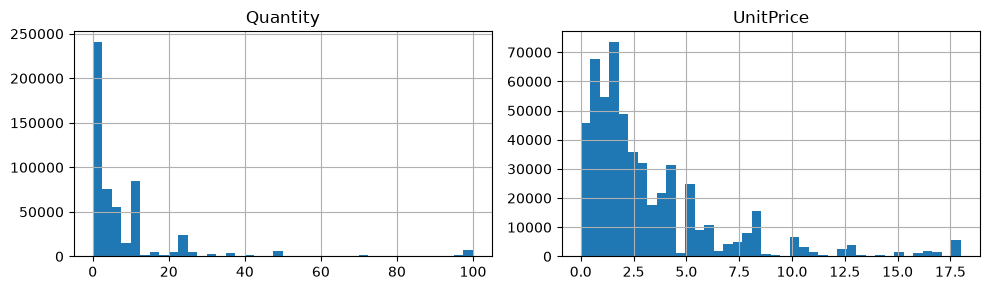

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import joblib
import kagglehub

path = kagglehub.dataset_download("hellbuoy/online-retail-customer-clustering")
print('File dataset:', path)

df = pd.read_csv(path + '/OnlineRetail.csv', encoding='latin1', parse_dates=['InvoiceDate'], date_format='%d-%m-%Y %H:%M')

print('Ukuran dataset:', df.shape)

print('Tipe data:')
print(df.dtypes)
display(df.head())

print('Missing value:\n', df.isna().sum())

print('Duplikat:', df.duplicated().sum())

print('Pelanggan unik:', df['CustomerID'].nunique())

print('Invoice unik:', df['InvoiceNo'].nunique())

print('Rentang tanggal:', df['InvoiceDate'].min(), 's.d.', df['InvoiceDate'].max())

print('Invoice pembatalan:', df['InvoiceNo'].str.startswith('C').sum())

print('Quantity <= 0:', (df['Quantity'] <= 0).sum(), '| UnitPrice <= 0:', (df['UnitPrice'] <= 0).sum())

display(df[['Quantity', 'UnitPrice']].describe())

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, column in zip(axes, ['Quantity', 'UnitPrice']):
    df[column].clip(lower=0, upper=df[column].quantile(.99)).hist(bins=40, ax=ax)
    ax.set_title(f'{column}')
plt.tight_layout()
plt.show()


#### 3. Data Preparation

##### Data Cleaning
- Menghapus data tanpa `CustomerID`.
- Mengubah `InvoiceDate` menjadi tipe `datetime`.
- Menghapus transaksi yang tidak valid.
- Menghapus atau menangani transaksi dengan `Quantity` <= 0.
- Menghapus atau menangani transaksi dengan `UnitPrice` <= 0.
- Memeriksa duplicate.

Dataset memang memiliki missing value cukup besar pada `CustomerID`, sehingga tahap cleaning penting dilakukan.

##### Feature Engineering

`Recency`: `Reference Date` - tanggal transaksi terakhir customer.

`Frequency`: Jumlah `InvoiceNo` unik per `CustomerID`.

`Monetary`: `TotalPrice` = `Quantity * UnitPrice` ; `Monetary` = `total TotalPrice per CustomerID`

Final Dataset: CustomerID | Recency | Frequency | Monetary

##### Preprocessing
- Cek distribusi RFM
- Handle Outlier
- Scaling dengan `StandardScaler`
- Dataset masuk `Recency`, `Frequency`, `Monetary`
- `CustomerID` sebagai indetifier, bukan fitur

Baris setelah cleaning: 392692 | Pelanggan: 4338 | Tanggal referensi: 2011-12-10


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,3,7,4310.00
2,12348,76,4,1797.24
3,12349,19,1,1757.55
4,12350,311,1,334.40


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,93.059474,4.272015,2048.688081
std,100.012264,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.750000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


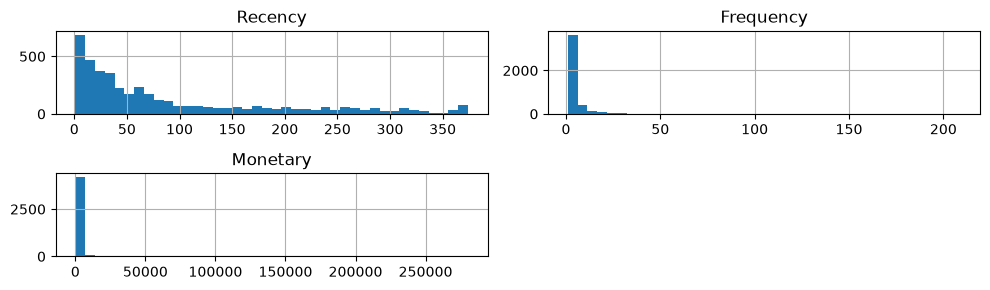

In [2]:
clean = df.dropna(subset=['CustomerID']).drop_duplicates().copy()

clean = clean[(~clean['InvoiceNo'].str.startswith('C')) & (clean['Quantity'] > 0) & (clean['UnitPrice'] > 0)].copy()

clean['CustomerID'] = clean['CustomerID'].astype(int)

clean['TotalPrice'] = clean['Quantity'] * clean['UnitPrice']

reference_date = clean['InvoiceDate'].max().normalize() + pd.Timedelta(days=1)

rfm = clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda dates: (reference_date - dates.max().normalize()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum'),
).reset_index()

print('Baris setelah cleaning:', len(clean), '| Pelanggan:', len(rfm), '| Tanggal referensi:', reference_date.date())
display(rfm.head())

display(rfm[['Recency', 'Frequency', 'Monetary']].describe())

rfm[['Recency', 'Frequency', 'Monetary']].hist(bins=40, figsize=(10, 3))
plt.tight_layout()
plt.show()

# Log1p menekan pengaruh nilai ekstrem tanpa membuang pelanggan.
features = ['Recency', 'Frequency', 'Monetary']
scaler = StandardScaler()
X = scaler.fit_transform(np.log1p(rfm[features]))


#### 4. Modeling

##### K-Means Clustering
Tahapan:
1. Menggunakan fitur RFM yang sudah distandardisasi.
2. Mencoba beberapa nilai jumlah cluster, misalnya k = 2–8.
3. Menggunakan Elbow Method untuk melihat jumlah cluster potensial.
4. Menggunakan Silhouette Score sebagai evaluasi tambahan.
5. Menentukan jumlah cluster.
6. Melatih model K-Means final.
7. Menambahkan label cluster ke masing-masing customer.

,k,Inertia,Silhouette
0,2,6476.506937,0.426661
1,3,4858.244056,0.328191
2,4,3925.425551,0.331229
3,5,3269.274700,0.317671
4,6,2841.417067,0.312671
5,7,2532.984679,0.307822
6,8,2325.075374,0.299203


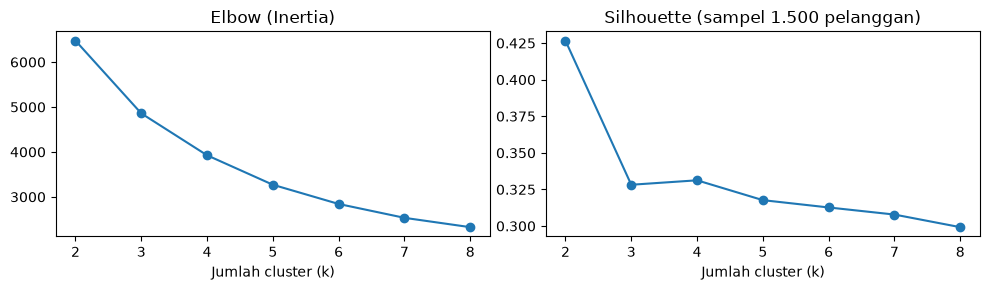

k terpilih: 2


In [3]:
scores = []

for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    scores.append((k, model.inertia_, silhouette_score(X, labels, sample_size=1500, random_state=42)))

results = pd.DataFrame(scores, columns=['k', 'Inertia', 'Silhouette'])

display(results)
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(results['k'], results['Inertia'], marker='o')
axes[0].set_title('Elbow (Inertia)')
axes[1].plot(results['k'], results['Silhouette'], marker='o')
axes[1].set_title('Silhouette (sampel 1.500 pelanggan)')
for ax in axes:
    ax.set_xlabel('Jumlah cluster (k)')
plt.tight_layout()
plt.show()

best_k = int(results.loc[results['Silhouette'].idxmax(), 'k'])
model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm['Cluster'] = model.fit_predict(X)
print('k terpilih:', best_k)


#### 5. Evaluation
Evaluasi model:
- Inertia / Elbow Method.
- Silhouette Score.
- Distribusi jumlah anggota setiap cluster.

Evaluasi bisnis:

Menghitung karakteristik rata-rata setiap cluster:
`Cluster | Avg Recency | Avg Frequency | Avg Monetary`

Cluster 0: `Low Recency + High Frequency + High Monetary → pelanggan aktif dengan nilai tinggi`

Cluster 1: `High Recency + Low Frequency + Low Monetary → pelanggan yang sudah lama tidak aktif`

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Segment
Cluster,,,,,
0,1668,26.45,8.44,4535.74,Segmen 1 (peringkat belanja 1)
1,2670,134.67,1.67,494.98,Segmen 2 (peringkat belanja 2)


Distribusi pelanggan:


Segment
Segmen 2 (peringkat belanja 2)    2670
Segmen 1 (peringkat belanja 1)    1668
Name: count, dtype: int64

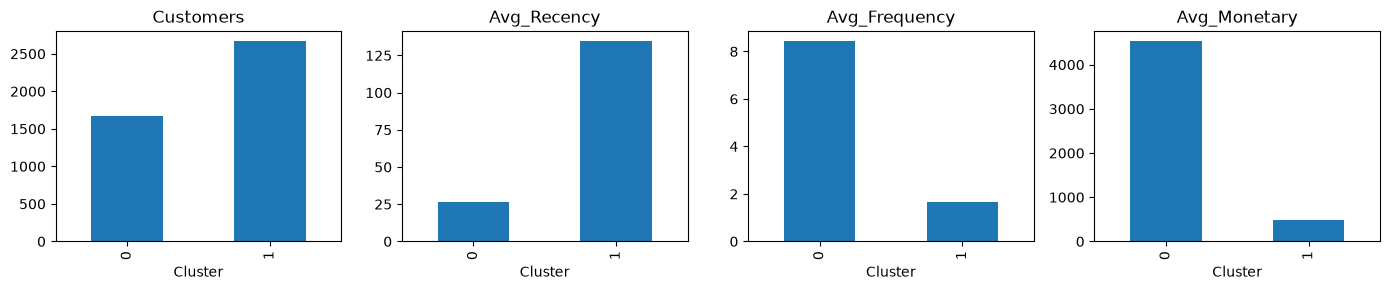

In [4]:
profile = rfm.groupby('Cluster').agg(
    Customers=('CustomerID', 'size'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
).round(2)

# Nama segmen mengikuti urutan nilai belanja rata-rata (tertinggi lebih dulu).
segment_names = {cluster: f'Segmen {rank} (peringkat belanja {rank})'
                 for rank, cluster in enumerate(profile['Avg_Monetary'].sort_values(ascending=False).index, 1)}

rfm['Segment'] = rfm['Cluster'].map(segment_names)
profile['Segment'] = profile.index.map(segment_names)
display(profile)

print('Distribusi pelanggan:')
display(rfm['Segment'].value_counts())
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, column in zip(axes, ['Customers', 'Avg_Recency', 'Avg_Frequency', 'Avg_Monetary']):
    profile[column].plot.bar(ax=ax, title=column)
plt.tight_layout()
plt.show()


**Interpretasi:** Recency kecil = lebih aktif; Frequency tinggi = lebih sering membeli; Monetary tinggi = lebih besar nilai belanja. Gunakan tabel profil di atas untuk menyusun kampanye setiap segmen. Nomor segmen diurutkan menurut rata-rata belanja, bukan kategori perilaku yang diasumsikan sebelumnya.


#### 6. Deployment
Output deployment:
- `CustomerID`
- `Recency`
- `Frequency`
- `Monetary`
- `Cluster`
- `Segment`

Implementasi:
- file CSV hasil segmentasi
- dashboard sederhana
- atau Streamlit untuk melihat profil setiap cluster.

Dashboard:
- Jumlah Customer
- Jumlah Cluster
- Distribusi Customer per Cluster
- Rata-rata RFM per Cluster
- Daftar Customer per Segment

Artifact:
- Scaler
- K-Means Model

In [5]:
output = Path('.')

rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment']].to_csv(output / 'segmentasi_pelanggan.csv', index=False)
joblib.dump(scaler, output / 'rfm_scaler.joblib')
joblib.dump(model, output / 'rfm_kmeans.joblib')
print('File hasil:', output / 'segmentasi_pelanggan.csv')
print('Jumlah pelanggan:', len(rfm), '| Jumlah cluster:', best_k)
display(rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segment']].head(10))


File hasil: segmentasi_pelanggan.csv
Jumlah pelanggan: 4338 | Jumlah cluster: 2


,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346,326,1,77183.60,0,Segmen 1 (peringkat belanja 1)
1,12347,3,7,4310.00,0,Segmen 1 (peringkat belanja 1)
2,12348,76,4,1797.24,0,Segmen 1 (peringkat belanja 1)
3,12349,19,1,1757.55,1,Segmen 2 (peringkat belanja 2)
4,12350,311,1,334.40,1,Segmen 2 (peringkat belanja 2)
5,12352,37,8,2506.04,0,Segmen 1 (peringkat belanja 1)
6,12353,205,1,89.00,1,Segmen 2 (peringkat belanja 2)
7,12354,233,1,1079.40,1,Segmen 2 (peringkat belanja 2)
8,12355,215,1,459.40,1,Segmen 2 (peringkat belanja 2)
9,12356,23,3,2811.43,0,Segmen 1 (peringkat belanja 1)
